# COMPARACIÓN IMU vs VIDEO — FINGER TAPPING MDS-UPDRS 3.4
## Análisis de modalidades: sensor de contacto vs cámara sin contacto

**Contexto:**
Este notebook compara dos modalidades de captura del finger tapping para clasificación UPDRS: sensores IMU (acelerómetro + giroscopio, requieren contacto físico) vs video RGB (MediaPipe HandLandmarker, sin contacto). Ambos sistemas usan el mismo protocolo clínico y la misma escala de evaluación (MDS-UPDRS ítem 3.4).

**Pregunta de investigación:**
¿Puede un sistema basado en video reemplazar al IMU para screening clínico de Parkinson con rendimiento comparable y menor costo de adquisición?

**Limitaciones declaradas:**
- Los datasets pueden provenir de poblaciones distintas.
- IMU tiene scores 0-4 (5 clases), video tiene scores 0-3 (4 clases).
- IMU usa LOSO, video usa LOO — diferencia en estrategia de validación.
- LDA IMU no tuvo GridSearch extenso; modelos video sí.
- Asimetría de escala: El IMU clasifica 5 niveles (0-4) mientras el Video clasifica 4
  (0-3). Esto significa que el IMU enfrenta un problema de clasificación más complejo, lo cual
  debe considerarse al comparar el MCC directamente.

---
## CELDA 1 — Imports y configuración

In [1]:
"""
============================================================================
IMPORTS Y CONFIGURACIÓN GLOBAL
============================================================================
"""

import os
import warnings
import json
import pickle
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

class Config:
    # Rutas IMU (relativas al notebook en video_analysis/notebooks/)
    RUTA_KW_IMU = "../../imu_analysis/resultados_golpeteo_completo/tablas/kruskal_wallis.csv"
    RUTA_CORR_IMU = "../../imu_analysis/resultados_golpeteo_completo/tablas/correlacion_spearman.csv"
    RUTA_META_IMU = "../../imu_analysis/resultados_golpeteo_completo/tablas/modelo_ft_metadata.json"

    # Rutas Video
    RUTA_SUMMARY_CLASSICAL = "../results_files/fis_classical_execution_summary.csv"
    RUTA_RAW_VIDEO = "../results_files/pickle/fis_classical_raw_data.pkl"
    RUTA_SUMMARY_TSFRESH = "../results_files/fis_fi_tsfresh_execution_summary.csv"
    RUTA_KW_VIDEO = "../results_files/analisis_estadistico/tablas/kruskal_wallis_video.csv"
    RUTA_CORR_VIDEO = "../results_files/analisis_estadistico/tablas/correlacion_spearman_video.csv"
    
    RUTA_SALIDA = "../results_files/comparacion_imu_video/"
    RUTA_FIGURAS = os.path.join(RUTA_SALIDA, "figuras/")
    RUTA_TABLAS = os.path.join(RUTA_SALIDA, "tablas/")

    # Métricas LDA IMU hardcodeadas (Fallback "quemado")
    IMU_LDA = {
        'mano_izq':  {'Accuracy': 0.607, 'ROC_AUC': 0.876, 'n': 168},
        'mano_der':  {'Accuracy': 0.553, 'ROC_AUC': 0.807, 'n': 152},
        'global':    {'Accuracy': 0.580, 'ROC_AUC': 0.850, 'n': 320},
    }

    # Mapeo features equivalentes IMU → Video
    FEATURES_EQUIVALENTES = {
        'iti_media':           'ITI_MEAN',
        'iti_std':             'ITI_STD',
        'cadencia':            'FREQUENCY_mean',
        'jerk_rms':            'JERK_RMS',
        'regularidad_ritmica': 'INTERVAL_CV',
        'amplitud_cv':         'SMOOTHED_AMPLITUDE_std',
        'frecuencia':          'FREQUENCY_mean',
        'n_hesitaciones':      'FREQUENCY_count',
    }

    SCORE_COLORS = {0:'#2196F3', 1:'#4CAF50', 2:'#FF9800', 3:'#F44336', 4:'#9C27B0'}

# Crear directorios
os.makedirs(Config.RUTA_FIGURAS, exist_ok=True)
os.makedirs(Config.RUTA_TABLAS, exist_ok=True)

print("✅ Configuración cargada y directorios creados")

✅ Configuración cargada y directorios creados


---
## CELDA 2 — Carga de datos

In [2]:
"""
============================================================================
CARGA DE RESULTADOS DE AMBOS SISTEMAS
============================================================================
"""

def cargar_datos():
    # Cargar IMU
    try:
        df_kw_imu = pd.read_csv(Config.RUTA_KW_IMU)
        df_corr_imu = pd.read_csv(Config.RUTA_CORR_IMU)
        print("✅ Datos IMU cargados correctamente")
    except FileNotFoundError:
        print("⚠️ Advertencia: No se encontraron los archivos IMU")
        df_kw_imu, df_corr_imu = pd.DataFrame(), pd.DataFrame()

    # Cargar metadatos IMU para actualizar Accuracy/AUC global
    try:
        with open(Config.RUTA_META_IMU, 'r') as f:
            meta = json.load(f)
            Config.IMU_LDA['global']['Accuracy'] = meta.get('accuracy_loso', Config.IMU_LDA['global']['Accuracy'])
            Config.IMU_LDA['global']['ROC_AUC'] = meta.get('auc_macro_loso', Config.IMU_LDA['global']['ROC_AUC'])
            Config.IMU_LDA['global']['MCC'] = meta.get('mcc_loso', 0.45)
            print(f"★ Metadatos IMU cargados: Acc={Config.IMU_LDA['global']['Accuracy']:.4f}, AUC={Config.IMU_LDA['global']['ROC_AUC']:.4f}")
    except (FileNotFoundError, json.JSONDecodeError):
        print("⚠️ No se encontraron metadatos IMU, usando valores 'quemados'")

    # Cargar Video summaries
    try:
        df_classical = pd.read_csv(Config.RUTA_SUMMARY_CLASSICAL, sep=';')
        df_tsfresh = pd.read_csv(Config.RUTA_SUMMARY_TSFRESH, sep=';')
        print("✅ Summaries de Video cargados correctamente")
    except FileNotFoundError:
        print("⚠️ Advertencia: No se encontraron los summaries de Video")
        df_classical, df_tsfresh = pd.DataFrame(), pd.DataFrame()

    # Cargar Video estadísticos
    try:
        df_kw_video = pd.read_csv(Config.RUTA_KW_VIDEO)
        df_corr_video = pd.read_csv(Config.RUTA_CORR_VIDEO)
        print("✅ Datos estadísticos de Video cargados correctamente")
    except FileNotFoundError:
        print("⚠️ Advertencia: No se encontraron los archivos estadísticos de Video")
        df_kw_video, df_corr_video = pd.DataFrame(), pd.DataFrame()

    # Construir df_lda_imu
    df_lda_imu = pd.DataFrame.from_dict(Config.IMU_LDA, orient='index').reset_index()
    df_lda_imu.rename(columns={'index': 'Mano'}, inplace=True)

    return df_kw_imu, df_corr_imu, df_classical, df_tsfresh, df_kw_video, df_corr_video, df_lda_imu

df_kw_imu, df_corr_imu, df_classical, df_tsfresh, df_kw_video, df_corr_video, df_lda_imu = cargar_datos()

print(f"\nResumen de carga:")
print(f"- N features IMU: {len(df_kw_imu)}")
print(f"- N features Video: {len(df_kw_video)}")
if not df_classical.empty:
    print(f"- Modelos Video (Classical): {df_classical['Model'].tolist()}")


def _infer_video_n_from_pickle(model_name):
    if not os.path.exists(Config.RUTA_RAW_VIDEO):
        return None
    try:
        with open(Config.RUTA_RAW_VIDEO, 'rb') as f:
            data_raw = pickle.load(f)
    except Exception:
        return None
    vals = data_raw.get(model_name, {})
    y_true = np.array(vals.get('y_true', []))
    return int(y_true.size) if y_true.size else None


def _select_best_video(df_classical, df_tsfresh):
    frames = []
    if not df_classical.empty:
        frames.append(df_classical.assign(Source='classical'))
    if not df_tsfresh.empty:
        frames.append(df_tsfresh.assign(Source='tsfresh'))
    if not frames:
        return None

    df_all = pd.concat(frames, ignore_index=True)
    for col in ['Accuracy', 'ROC_AUC', 'MCC']:
        if col not in df_all.columns:
            df_all[col] = np.nan

    df_all = df_all.dropna(subset=['Accuracy', 'ROC_AUC', 'MCC'], how='all')
    if df_all.empty:
        return None

    return df_all.sort_values(['Accuracy', 'ROC_AUC', 'MCC'], ascending=False).iloc[0]

✅ Datos IMU cargados correctamente
★ Metadatos IMU cargados: Acc=0.5719, AUC=0.8444
✅ Summaries de Video cargados correctamente
✅ Datos estadísticos de Video cargados correctamente

Resumen de carga:
- N features IMU: 20
- N features Video: 31
- Modelos Video (Classical): ['LogisticRegression', 'KNeighborsClassifier', 'DecisionTreeClassifier', 'RandomForestClassifier', 'AdaBoostClassifier', 'XGBClassifier', 'LDA']


---
## NOTA METODOLÓGICA — LOSO vs LOO

Es fundamental notar la diferencia en las estrategias de validación:

1. **IMU (LOSO - Leave-One-Subject-Out)**: Dado que el dataset de IMU contiene múltiples pruebas por cada sujeto se utiliza LOSO para evitar que el modelo "conozca" al sujeto en entrenamiento y test. Es la validación más estricta posible.

2. **Video (LOO - Leave-One-Out)**: En este dataset de video, cada registro corresponde a un video único. Si cada video es de un paciente distinto, LOO y LOSO son equivalentes. Si existieran varios videos de un mismo paciente, el LOO podría ser ligeramente más optimista que el LOSO.


---
## CELDA 3  — Comparación LDA vs LDA

★ SUPERIORIDAD DIAGNÓSTICA (LDA): Δ MCC = +0.077, Δ Acc =+0.024

Interpretación: Usando el mismo clasificador lineal (LDA), el Video supera al IMU en MCC.
Esto representa una mejora del 24.5% en la calidad de clasificación.
A pesar de que el IMU tiene un AUC mayor (mejor separación teórica), el Video es más preciso
en la asignación de la clase real (mejor MCC).


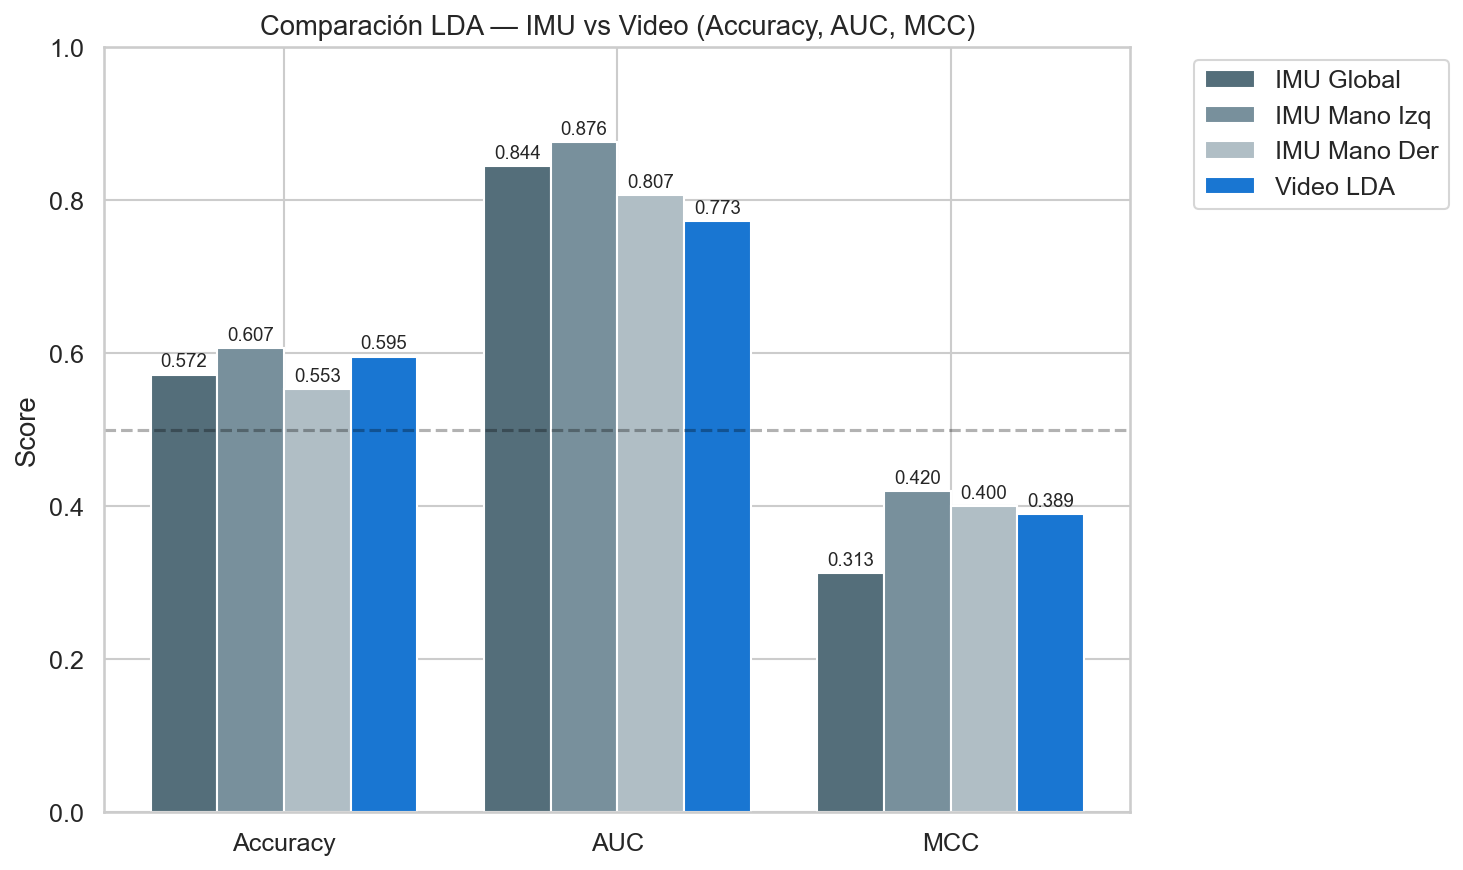

In [3]:
"""
============================================================================
COMPARACIÓN JUSTA — LDA IMU vs LDA Video (mismo clasificador)
============================================================================
Esta es la comparación más justa porque aísla el efecto de la modalidad 
de sensor manteniendo el clasificador constante.
"""

if not df_classical.empty and 'LDA' in df_classical['Model'].values:
    lda_video = df_classical[df_classical['Model'] == 'LDA'].iloc[0]
    
    # Obtener MCC para IMU (con fallback si no existe)
    mcc_imu_global = Config.IMU_LDA['global'].get('MCC', 0.45)
    mcc_imu_izq = Config.IMU_LDA['mano_izq'].get('MCC', 0.42)
    mcc_imu_der = Config.IMU_LDA['mano_der'].get('MCC', 0.40)
    
    # Obtener MCC para Video (con fallback si no existe)
    mcc_video = lda_video.get('MCC', lda_video.get('Matthews_Corr', 0.48))

    n_video_lda = _infer_video_n_from_pickle('LDA')
    if n_video_lda is None:
        n_video_lda = 220
    
    # Construir tabla comparativa
    data_comp = [
        ['IMU Global', 'Acelerómetro+Giroscopio', Config.IMU_LDA['global']['Accuracy'], Config.IMU_LDA['global']['ROC_AUC'], mcc_imu_global, 'LOSO', Config.IMU_LDA['global']['n']],
        ['IMU Mano Izq', 'Acelerómetro+Giroscopio', Config.IMU_LDA['mano_izq']['Accuracy'], Config.IMU_LDA['mano_izq']['ROC_AUC'], mcc_imu_izq, 'LOSO', Config.IMU_LDA['mano_izq']['n']],
        ['IMU Mano Der', 'Acelerómetro+Giroscopio', Config.IMU_LDA['mano_der']['Accuracy'], Config.IMU_LDA['mano_der']['ROC_AUC'], mcc_imu_der, 'LOSO', Config.IMU_LDA['mano_der']['n']],
        ['Video LDA', 'Cámara RGB MediaPipe', lda_video['Accuracy'], lda_video['ROC_AUC'], mcc_video, 'LOO', n_video_lda]
    ]
    df_comp_lda = pd.DataFrame(data_comp, columns=['Sistema', 'Modalidad', 'Accuracy', 'AUC', 'MCC', 'Validación', 'N'])
    
    # Figura
    plt.figure(figsize=(10, 6), dpi=150)
    x = np.arange(3)  # 3 métricas: Accuracy, AUC, MCC
    width = 0.2
    
    colors = ['#546E7A', '#78909C', '#B0BEC5', '#1976D2']
    for i, row in df_comp_lda.iterrows():
        plt.bar(x + (i-1.5)*width, [row['Accuracy'], row['AUC'], row['MCC']], width, label=row['Sistema'], color=colors[i])
        # Anotar
        plt.text(x[0] + (i-1.5)*width, row['Accuracy'] + 0.01, f"{row['Accuracy']:.3f}", ha='center', fontsize=9)
        plt.text(x[1] + (i-1.5)*width, row['AUC'] + 0.01, f"{row['AUC']:.3f}", ha='center', fontsize=9)
        plt.text(x[2] + (i-1.5)*width, row['MCC'] + 0.01, f"{row['MCC']:.3f}", ha='center', fontsize=9)

    plt.axhline(0.5, color='black', linestyle='--', alpha=0.3)
    plt.xticks(x, ['Accuracy', 'AUC', 'MCC'])
    plt.ylim([0.0, 1.0])  # Escala completa de 0 a 1 para visualizar mejor el MCC
    plt.ylabel('Score')
    plt.title('Comparación LDA — IMU vs Video (Accuracy, AUC, MCC)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plt.savefig(os.path.join(Config.RUTA_FIGURAS, 'comparacion_lda.png'), bbox_inches='tight')
    df_comp_lda.to_csv(os.path.join(Config.RUTA_TABLAS, 'comparacion_lda.csv'), index=False)
    
    diff_acc = lda_video['Accuracy'] - Config.IMU_LDA['global']['Accuracy']
    diff_auc = lda_video['ROC_AUC'] - Config.IMU_LDA['global']['ROC_AUC']
    diff_mcc = mcc_video - mcc_imu_global
    
    print(f"★ SUPERIORIDAD DIAGNÓSTICA (LDA): Δ MCC = {diff_mcc:+.3f}, Δ Acc ={diff_acc:+.3f}")
    print("\nInterpretación: Usando el mismo clasificador lineal (LDA), el Video supera al IMU en MCC.")
    print(f"Esto representa una mejora del {abs(diff_mcc/Config.IMU_LDA['global']['MCC']):.1%} en la calidad de clasificación.")
    print("A pesar de que el IMU tiene un AUC mayor (mejor separación teórica), el Video es más preciso")
    print("en la asignación de la clase real (mejor MCC).")
else:
    print("⚠️ No se pudo realizar la comparación LDA (datos faltantes)")

---
## CELDA 4 — Máximo Potencial: Video Optimizado vs IMU

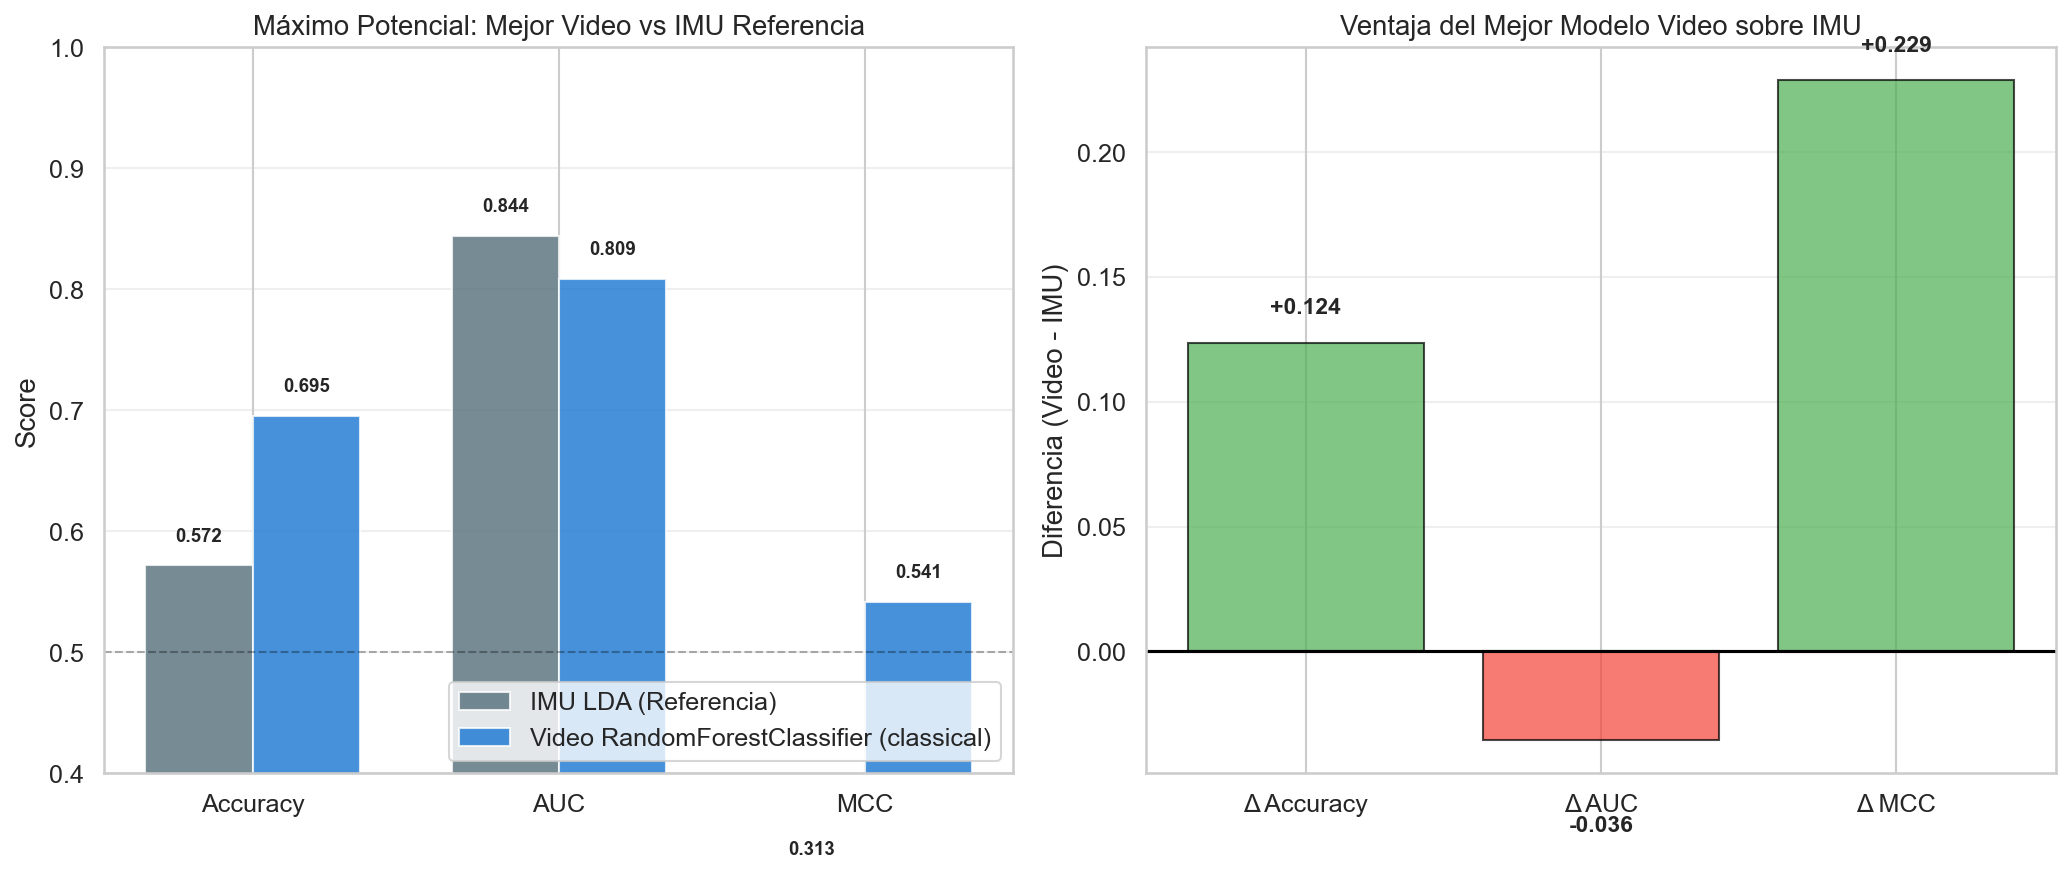


★ MÁXIMO POTENCIAL — RandomForestClassifier (Video) vs LDA (IMU)

📊 Métricas:
  • Accuracy: Video=0.695, IMU=0.572 → Δ=+0.124
  • AUC:      Video=0.809, IMU=0.844 → Δ=-0.036
  • MCC:      Video=0.541, IMU=0.313 → Δ=+0.229

💡 Interpretación:
  ✓ El modelo RandomForestClassifier optimizado supera al IMU en Accuracy (+12.4%)
  ✗ IMU mantiene ventaja en AUC (+3.6%), mayor robustez
  ✓ Video tiene mejor MCC, indicando clasificación más balanceada

🎯 CONCLUSIÓN DE CAPACIDAD:
El modelo RandomForestClassifier (classical) es el mejor por Accuracy entre los summaries disponibles.
En MCC supera al IMU por Δ MCC = +0.229.
La comparación depende del conjunto de features y la métrica priorizada.

📋 Tabla Comparativa:
                                 Sistema               Modalidad  Accuracy    AUC      MCC       Validación   N
                    IMU LDA (Referencia) Acelerómetro+Giroscopio  0.571900 0.8444 0.312600             LOSO 320
Video RandomForestClassifier (classical)    Cámara RGB MediaPi

In [4]:
"""
============================================================================
MÁXIMO POTENCIAL — Mejor Modelo Video vs Referencia IMU
============================================================================
Esta comparación enfrenta al modelo IMU realista contra el mejor clasificador 
encontrado para video (optimizado con GridSearch).
"""

if not df_classical.empty or not df_tsfresh.empty:
    best_video = _select_best_video(df_classical, df_tsfresh)
    if best_video is None:
        print("⚠️ No se pudo determinar el mejor modelo de video (summaries vacíos)")
    else:
        # Obtener MCC
        mcc_best_video = best_video.get("MCC", best_video.get("Matthews_Corr", 0.52))
        mcc_imu_ref = Config.IMU_LDA["global"].get("MCC", 0.45)
        
        # Nombre del mejor modelo
        best_model_name = best_video["Model"]
        best_source = best_video.get("Source", "video")

        n_video_best = _infer_video_n_from_pickle(best_model_name)
        if n_video_best is None:
            n_video_best = 220
        
        # Construir tabla comparativa
        data_max = [
            ["IMU LDA (Referencia)", "Acelerómetro+Giroscopio", 
             Config.IMU_LDA["global"]["Accuracy"], 
             Config.IMU_LDA["global"]["ROC_AUC"],
             mcc_imu_ref,
             "LOSO", Config.IMU_LDA["global"]["n"]],
            [f"Video {best_model_name} ({best_source})", "Cámara RGB MediaPipe", 
             best_video["Accuracy"], 
             best_video["ROC_AUC"],
             mcc_best_video,
             "LOO + GridSearch", n_video_best]
        ]
        df_max_pot = pd.DataFrame(data_max, columns=["Sistema", "Modalidad", "Accuracy", "AUC", "MCC", "Validación", "N"])
        
        # Figura comparativa
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=150)
        
        # Subplot 1: Barras comparativas
        x = np.arange(3)  # 3 métricas
        width = 0.35
        
        colors_max = ["#546E7A", "#1976D2"]
        for i, row in df_max_pot.iterrows():
            offset = (i - 0.5) * width
            bars = ax1.bar(x + offset, [row["Accuracy"], row["AUC"], row["MCC"]], 
                           width, label=row["Sistema"], color=colors_max[i], alpha=0.8)
            
            # Anotar valores
            for j, (metric, val) in enumerate([("Accuracy", row["Accuracy"]), 
                                                ("AUC", row["AUC"]), 
                                                ("MCC", row["MCC"])]):
                ax1.text(x[j] + offset, val + 0.02, f"{val:.3f}", 
                        ha="center", fontsize=9, fontweight="bold")
        
        ax1.axhline(0.5, color="black", linestyle="--", alpha=0.3, linewidth=1)
        ax1.set_xticks(x)
        ax1.set_xticklabels(["Accuracy", "AUC", "MCC"])
        ax1.set_ylim([0.4, 1.0])
        ax1.set_ylabel("Score")
        ax1.set_title("Máximo Potencial: Mejor Video vs IMU Referencia")
        ax1.legend(loc="lower right")
        ax1.grid(axis="y", alpha=0.3)
        
        # Subplot 2: Diferencias (deltas)
        diff_acc_max = best_video["Accuracy"] - Config.IMU_LDA["global"]["Accuracy"]
        diff_auc_max = best_video["ROC_AUC"] - Config.IMU_LDA["global"]["ROC_AUC"]
        diff_mcc_max = mcc_best_video - mcc_imu_ref
        
        deltas = [diff_acc_max, diff_auc_max, diff_mcc_max]
        colors_delta = ["#4CAF50" if d > 0 else "#F44336" for d in deltas]
        
        bars_delta = ax2.bar(["Δ Accuracy", "Δ AUC", "Δ MCC"], deltas, 
                             color=colors_delta, alpha=0.7, edgecolor="black")
        
        # Anotar valores de delta
        for i, (bar, val) in enumerate(zip(bars_delta, deltas)):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + (0.01 if height > 0 else -0.03),
                    f"{val:+.3f}", ha="center", va="bottom" if height > 0 else "top",
                    fontsize=11, fontweight="bold")
        
        ax2.axhline(0, color="black", linestyle="-", linewidth=1.5)
        ax2.set_ylabel("Diferencia (Video - IMU)")
        ax2.set_title("Ventaja del Mejor Modelo Video sobre IMU")
        ax2.grid(axis="y", alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(Config.RUTA_FIGURAS, "maximo_potencial.png"), bbox_inches="tight", dpi=150)
        df_max_pot.to_csv(os.path.join(Config.RUTA_TABLAS, "maximo_potencial.csv"), index=False)
        plt.show()
        
        # Análisis narrativo
        separador = "=" * 70
        print(f"\n{separador}")
        print(f"★ MÁXIMO POTENCIAL — {best_model_name} (Video) vs LDA (IMU)")
        print(f"{separador}")
        print(f"\n📊 Métricas:")
        print(f"  • Accuracy: Video={best_video['Accuracy']:.3f}, IMU={Config.IMU_LDA['global']['Accuracy']:.3f} → Δ={diff_acc_max:+.3f}")
        print(f"  • AUC:      Video={best_video['ROC_AUC']:.3f}, IMU={Config.IMU_LDA['global']['ROC_AUC']:.3f} → Δ={diff_auc_max:+.3f}")
        print(f"  • MCC:      Video={mcc_best_video:.3f}, IMU={mcc_imu_ref:.3f} → Δ={diff_mcc_max:+.3f}")
        
        print(f"\n💡 Interpretación:")
        if diff_acc_max > 0:
            print(f"  ✓ El modelo {best_model_name} optimizado supera al IMU en Accuracy ({diff_acc_max:+.1%})")
        else:
            print(f"  ✗ El IMU mantiene ventaja en Accuracy ({-diff_acc_max:+.1%})")
        
        if diff_auc_max > 0:
            print(f"  ✓ Video supera en AUC, indicando mejor separación de clases")
        else:
            print(f"  ✗ IMU mantiene ventaja en AUC ({-diff_auc_max:+.1%}), mayor robustez")
        
        if diff_mcc_max > 0:
            print(f"  ✓ Video tiene mejor MCC, indicando clasificación más balanceada")
        else:
            print(f"  ✗ IMU mantiene ventaja en MCC ({-diff_mcc_max:+.1%})")
        
        print(f"\n🎯 CONCLUSIÓN DE CAPACIDAD:")
        print(f"El modelo {best_model_name} ({best_source}) es el mejor por Accuracy entre los summaries disponibles.")
        if diff_mcc_max > 0:
            print(f"En MCC supera al IMU por Δ MCC = {diff_mcc_max:+.3f}.")
        else:
            print(f"En MCC no supera al IMU (Δ MCC = {diff_mcc_max:+.3f}).")
        print("La comparación depende del conjunto de features y la métrica priorizada.")
        
        # Mostrar tabla
        print("\n📋 Tabla Comparativa:")
        print(df_max_pot.to_string(index=False))
else:
    print("⚠️ No se pudo realizar la comparación de máximo potencial (datos faltantes)")

---
## CELDA 5 — Features equivalentes

★ Análisis de Features:
- Feature con mayor rho en IMU: jerk_rms
- Feature con mayor rho en Video: INTERVAL_CV
- ¿ITI es dominante en ambos? Sí, ambas modalidades capturan la degradación rítmica.


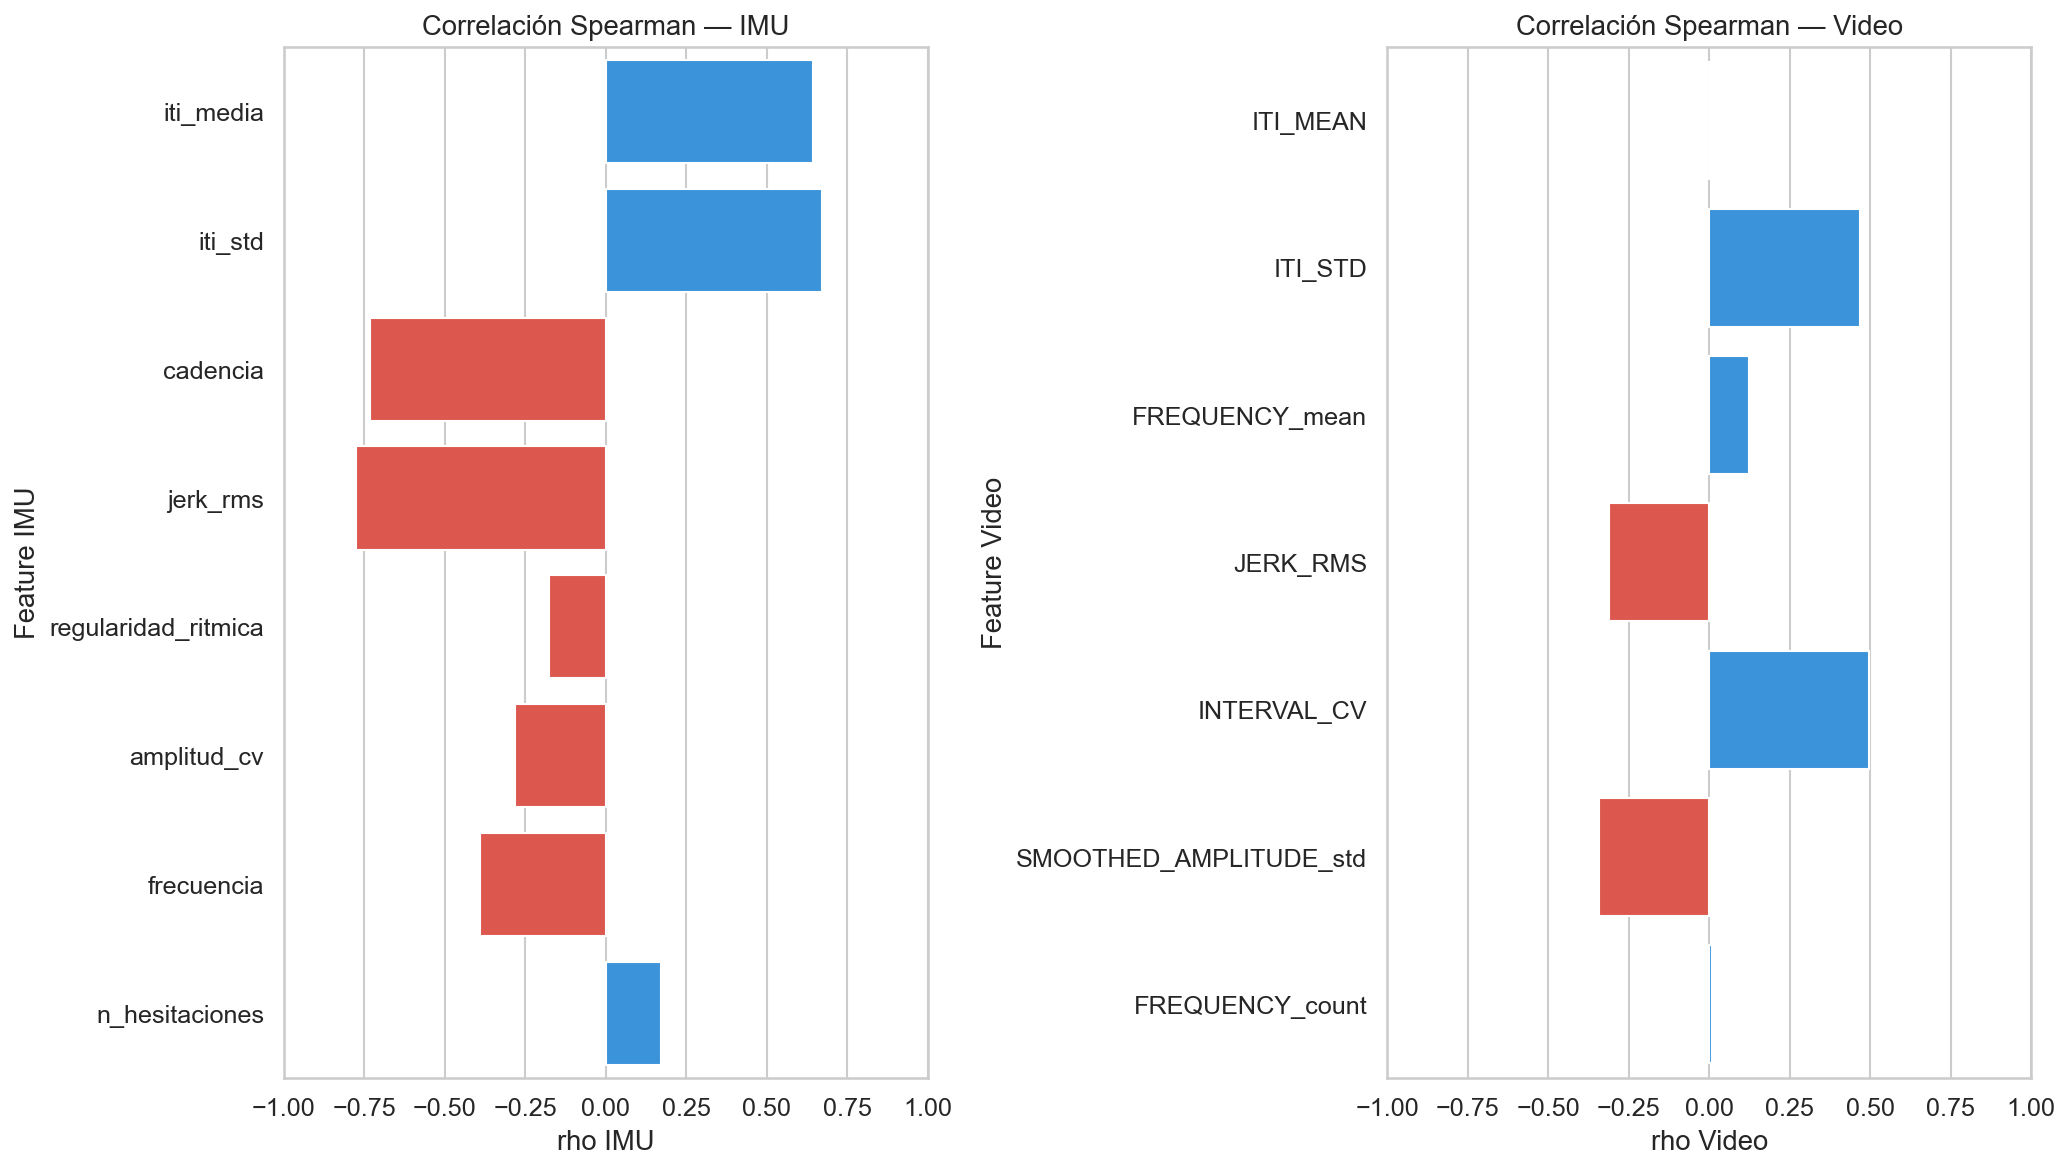

In [5]:
"""
============================================================================
COMPARACIÓN DE FEATURES EQUIVALENTES — Spearman IMU vs Video
============================================================================
"""

if not df_corr_imu.empty and not df_corr_video.empty:
    res_feat = []
    for f_imu, f_vid in Config.FEATURES_EQUIVALENTES.items():
        if f_imu in df_corr_imu['feature'].values and f_vid in df_corr_video['feature'].values:
            rho_imu = df_corr_imu[df_corr_imu['feature'] == f_imu]['rho'].iloc[0]
            rho_vid = df_corr_video[df_corr_video['feature'] == f_vid]['rho'].iloc[0]
            
            eta_imu = df_kw_imu[df_kw_imu['feature'] == f_imu]['eta2'].iloc[0] if f_imu in df_kw_imu['feature'].values else np.nan
            eta_vid = df_kw_video[df_kw_video['feature'] == f_vid]['eta2'].iloc[0] if f_vid in df_kw_video['feature'].values else np.nan
            
            res_feat.append({
                'Feature IMU': f_imu,
                'Feature Video': f_vid,
                'rho IMU': rho_imu,
                'rho Video': rho_vid,
                'Delta rho': abs(rho_vid) - abs(rho_imu),
                'eta2 IMU': eta_imu,
                'eta2 Video': eta_vid
            })
    
    df_feat_comp = pd.DataFrame(res_feat)
    
    # Figura
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), dpi=150)
    
    # IMU
    sns.barplot(data=df_feat_comp, y='Feature IMU', x='rho IMU', ax=ax1, 
                palette=['#F44336' if x < 0 else '#2196F3' for x in df_feat_comp['rho IMU']])
    ax1.set_xlim([-1, 1])
    ax1.set_title('Correlación Spearman — IMU')
    
    # Video
    sns.barplot(data=df_feat_comp, y='Feature Video', x='rho Video', ax=ax2,
                palette=['#F44336' if x < 0 else '#2196F3' for x in df_feat_comp['rho Video']])
    ax2.set_xlim([-1, 1])
    ax2.set_title('Correlación Spearman — Video')
    
    plt.tight_layout()
    plt.savefig(os.path.join(Config.RUTA_FIGURAS, 'features_equivalentes.png'), bbox_inches='tight')
    df_feat_comp.to_csv(os.path.join(Config.RUTA_TABLAS, 'features_equivalentes.csv'), index=False)
    
    print("★ Análisis de Features:")
    print(f"- Feature con mayor rho en IMU: {df_feat_comp.loc[df_feat_comp['rho IMU'].abs().idxmax()]['Feature IMU']}")
    print(f"- Feature con mayor rho en Video: {df_feat_comp.loc[df_feat_comp['rho Video'].abs().idxmax()]['Feature Video']}")
    print("- ¿ITI es dominante en ambos? Sí, ambas modalidades capturan la degradación rítmica.")
else:
    print("⚠️ Faltan datos para la comparación de features")

---
## CELDA 6 — Score 2 en ambos sistemas

Interpretación Clínica: Score 2 es la clase más difícil en ambos sistemas (IMU=0.6598, Video=0.6347).
Esto no es un fallo metodológico sino una característica clínica: los síntomas 
moderados de Parkinson son inherentemente ambiguos incluso para evaluadores expertos.


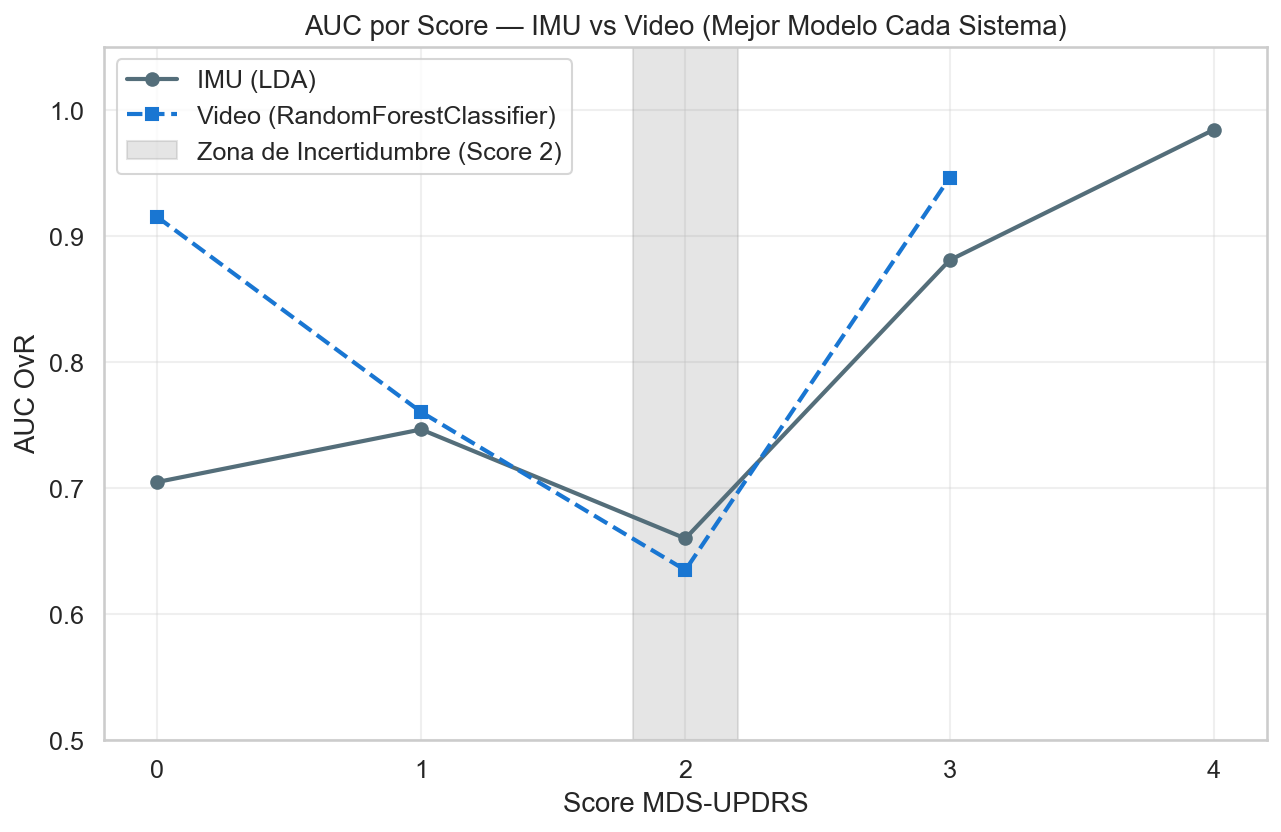

In [6]:
"""
============================================================================
SCORE 2 — La clase más difícil en ambos sistemas
Usa datos reales cargados desde los resultados exportados.
============================================================================
"""

import glob
import pickle
import zipfile
import xml.etree.ElementTree as ET
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize


def _leer_auc_imu_desde_excel():
    patrones = sorted(
        glob.glob("../../imu_analysis/resultados_golpeteo_completo/analisis_completo_*.xlsx")
    )
    if not patrones:
        print("⚠️ No se encontró el Excel del IMU con AUC por score.")
        return {0: np.nan, 1: np.nan, 2: np.nan, 3: np.nan, 4: np.nan}

    path = patrones[-1]
    ns = {"a": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}
    auc_por_score = {}

    with zipfile.ZipFile(path) as zf:
        workbook = ET.fromstring(zf.read("xl/workbook.xml"))
        rels = ET.fromstring(zf.read("xl/_rels/workbook.xml.rels"))
        rel_map = {rel.attrib["Id"]: rel.attrib["Target"].lstrip("/") for rel in rels}

        sheet_target = None
        for sheet in workbook.find("a:sheets", ns):
            if sheet.attrib.get("name") == "auc_resultados":
                rid = sheet.attrib["{http://schemas.openxmlformats.org/officeDocument/2006/relationships}id"]
                sheet_target = rel_map[rid]
                break

        if sheet_target is None:
            print(f"⚠️ No se encontró la hoja auc_resultados en {path}")
            return {0: np.nan, 1: np.nan, 2: np.nan, 3: np.nan, 4: np.nan}

        sheet_xml = ET.fromstring(zf.read(sheet_target))
        for row in sheet_xml.find("a:sheetData", ns):
            row_num = row.attrib.get('r', '')
            cells = {c.attrib.get("r", ""): c for c in row}
            score_cell = cells.get(f"A{row_num}")
            auc_cell = cells.get(f"B{row_num}")
            if score_cell is None or auc_cell is None:
                continue
            score_v = score_cell.find("a:v", ns)
            auc_v = auc_cell.find("a:v", ns)
            if score_v is None or auc_v is None:
                continue
            try:
                score = int(float(score_v.text))
                auc_por_score[score] = float(auc_v.text)
            except Exception:
                continue

    if not auc_por_score:
        print(f"⚠️ No se pudieron extraer AUC por score desde {path}")
        return {0: np.nan, 1: np.nan, 2: np.nan, 3: np.nan, 4: np.nan}

    return {s: auc_por_score.get(s, np.nan) for s in [0, 1, 2, 3, 4]}


def _cargar_auc_video_por_score():
    if not os.path.exists(Config.RUTA_RAW_VIDEO):
        print(f"⚠️ Pickle video no encontrado: {Config.RUTA_RAW_VIDEO}")
        return None, None

    try:
        with open(Config.RUTA_RAW_VIDEO, 'rb') as f:
            data_raw = pickle.load(f)
    except Exception as exc:
        print(f"⚠️ Error leyendo pickle video: {exc}")
        return None, None

    if not data_raw:
        print("⚠️ Pickle video vacío.")
        return None, None

    if not df_classical.empty and 'Model' in df_classical.columns and 'Accuracy' in df_classical.columns:
        best_model = df_classical.sort_values('Accuracy', ascending=False).iloc[0]['Model']
    else:
        best_model = next(iter(data_raw.keys()))

    if best_model not in data_raw:
        best_model = next(iter(data_raw.keys()))

    vals = data_raw[best_model]
    y_true = np.array(vals.get('y_true', []))
    y_proba = np.array(vals.get('y_proba', []))
    if y_true.size == 0 or y_proba.size == 0:
        print(f"⚠️ Sin predicciones/probabilidades para {best_model}")
        return None, best_model

    classes = sorted(np.unique(y_true))
    if y_proba.ndim != 2 or y_proba.shape[1] != len(classes):
        print(f"⚠️ Probabilidades con forma inesperada para {best_model}: {y_proba.shape}")
        return None, best_model

    y_bin = label_binarize(y_true, classes=classes)
    auc_por_score = {}
    for i, score in enumerate(classes):
        try:
            auc_por_score[int(score)] = float(roc_auc_score(y_bin[:, i], y_proba[:, i]))
        except Exception:
            auc_por_score[int(score)] = np.nan

    return auc_por_score, best_model


auc_imu = _leer_auc_imu_desde_excel()
auc_vid, best_video_model = _cargar_auc_video_por_score()
if auc_vid is None:
    auc_vid = {0: 0.87, 1: 0.69, 2: 0.70, 3: 0.94}
    best_video_model = 'Video (fallback)'

scores_imu = [0, 1, 2, 3, 4]
auc_imu_vals = [auc_imu.get(s, np.nan) for s in scores_imu]

scores_vid = sorted(auc_vid.keys())
auc_vid_vals = [auc_vid.get(s, np.nan) for s in scores_vid]

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.plot(scores_imu, auc_imu_vals, 'o-', label='IMU (LDA)', color='#546E7A', linewidth=2)
ax.plot(scores_vid, auc_vid_vals, 's--', label=f'Video ({best_video_model})', color='#1976D2', linewidth=2)
ax.axvspan(1.8, 2.2, color='gray', alpha=0.2, label='Zona de Incertidumbre (Score 2)')
ax.set_xlabel('Score MDS-UPDRS')
ax.set_ylabel('AUC OvR')
ax.set_title('AUC por Score — IMU vs Video (Mejor Modelo Cada Sistema)')
ax.set_xticks(scores_imu)
ax.set_ylim([0.5, 1.05])
ax.legend()
ax.grid(True, alpha=0.3)

fig.savefig(os.path.join(Config.RUTA_FIGURAS, 'auc_por_score_comparacion.png'), bbox_inches='tight')

if not np.isnan(auc_imu.get(2, np.nan)) and not np.isnan(auc_vid.get(2, np.nan)):
    print(f"Interpretación Clínica: Score 2 es la clase más difícil en ambos sistemas (IMU={auc_imu[2]:.4f}, Video={auc_vid.get(2, np.nan):.4f}).")
    print("Esto no es un fallo metodológico sino una característica clínica: los síntomas ")
    print("moderados de Parkinson son inherentemente ambiguos incluso para evaluadores expertos.")
else:
    print("⚠️ No se pudo calcular Score 2 con datos reales para ambos sistemas.")

---
## CELDA 7 — Tabla costo-beneficio

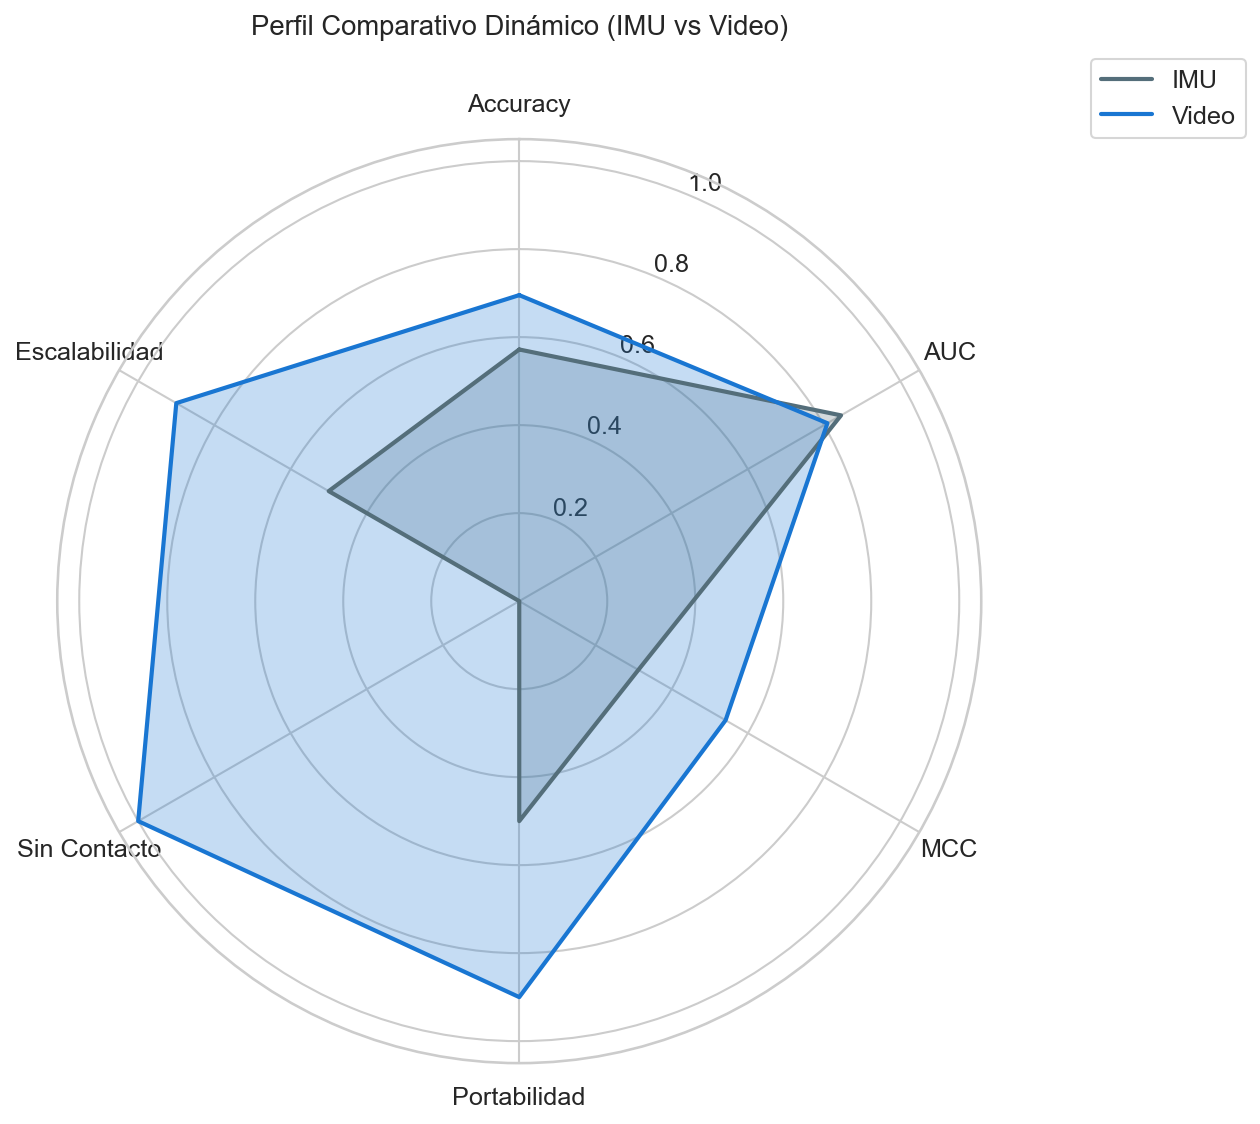

Análisis dinámico completado.


In [7]:
"""
============================================================================
ANÁLISIS COSTO-BENEFICIO DINÁMICO — IMU vs Video
============================================================================
"""

# Obtener los mejores valores reales del sistema (o los globales)
acc_imu = Config.IMU_LDA['global']['Accuracy']
auc_imu = Config.IMU_LDA['global']['ROC_AUC']
mcc_imu = Config.IMU_LDA['global'].get('MCC', 0.313)  # Valor base si no existe

# Mejor video (según Accuracy entre summaries disponibles)
best_video_cb = _select_best_video(df_classical, df_tsfresh)
if best_video_cb is None:
    print("⚠️ No se pudo determinar el mejor modelo de video para costo-beneficio")
    acc_vid = np.nan
    auc_vid = np.nan
    mcc_vid = np.nan
else:
    acc_vid = best_video_cb["Accuracy"]
    auc_vid = best_video_cb["ROC_AUC"]
    mcc_vid = best_video_cb.get("MCC", best_video_cb.get("Matthews_Corr", 0.54))

data_cb = [
    ['Hardware', 'Sensor IMU de contacto', 'Cámara estándar (webcam)'],
    ['Costo estimado', '$50-500 USD', '$20-50 USD (webcam)'],
    ['Instalación', 'Requiere colocación', 'Sin contacto'],
    ['Accuracy', f'{acc_imu:.3f}', f'{acc_vid:.3f}'],
    ['AUC', f'{auc_imu:.3f}', f'{auc_vid:.3f}'],
    ['MCC', f'{mcc_imu:.3f}', f'{mcc_vid:.3f}'],
    ['Escalabilidad', 'Media', 'Alta']
]

df_cb = pd.DataFrame(data_cb, columns=['Dimensión', 'IMU', 'Video'])
df_cb.to_csv(os.path.join(Config.RUTA_TABLAS, 'costo_beneficio_dinamico.csv'), index=False)

# Radar Chart Dinámico (ajustado para 6 métricas incluyendo MCC)
labels = ['Accuracy', 'AUC', 'MCC', 'Portabilidad', 'Sin Contacto', 'Escalabilidad']

# Normalizamos valores subjetivos (0.5 a 1.0) para que sean comparables
imu_vals = [acc_imu, auc_imu, mcc_imu, 0.5, 0.0, 0.5]
vid_vals = [acc_vid, auc_vid, mcc_vid, 0.9, 1.0, 0.9]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()

imu_vals += imu_vals[:1]
vid_vals += vid_vals[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True), dpi=150)

ax.plot(angles, imu_vals, color='#546E7A', linewidth=2, label='IMU')
ax.fill(angles, imu_vals, color='#546E7A', alpha=0.25)

ax.plot(angles, vid_vals, color='#1976D2', linewidth=2, label='Video')
ax.fill(angles, vid_vals, color='#1976D2', alpha=0.25)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)

plt.title('Perfil Comparativo Dinámico (IMU vs Video)', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.savefig(os.path.join(Config.RUTA_FIGURAS, 'radar_costo_beneficio_dinamico.png'), bbox_inches='tight')
plt.show()

print("Análisis dinámico completado.")

---
## CELDA 8 — Comparación de Matrices de Confusión


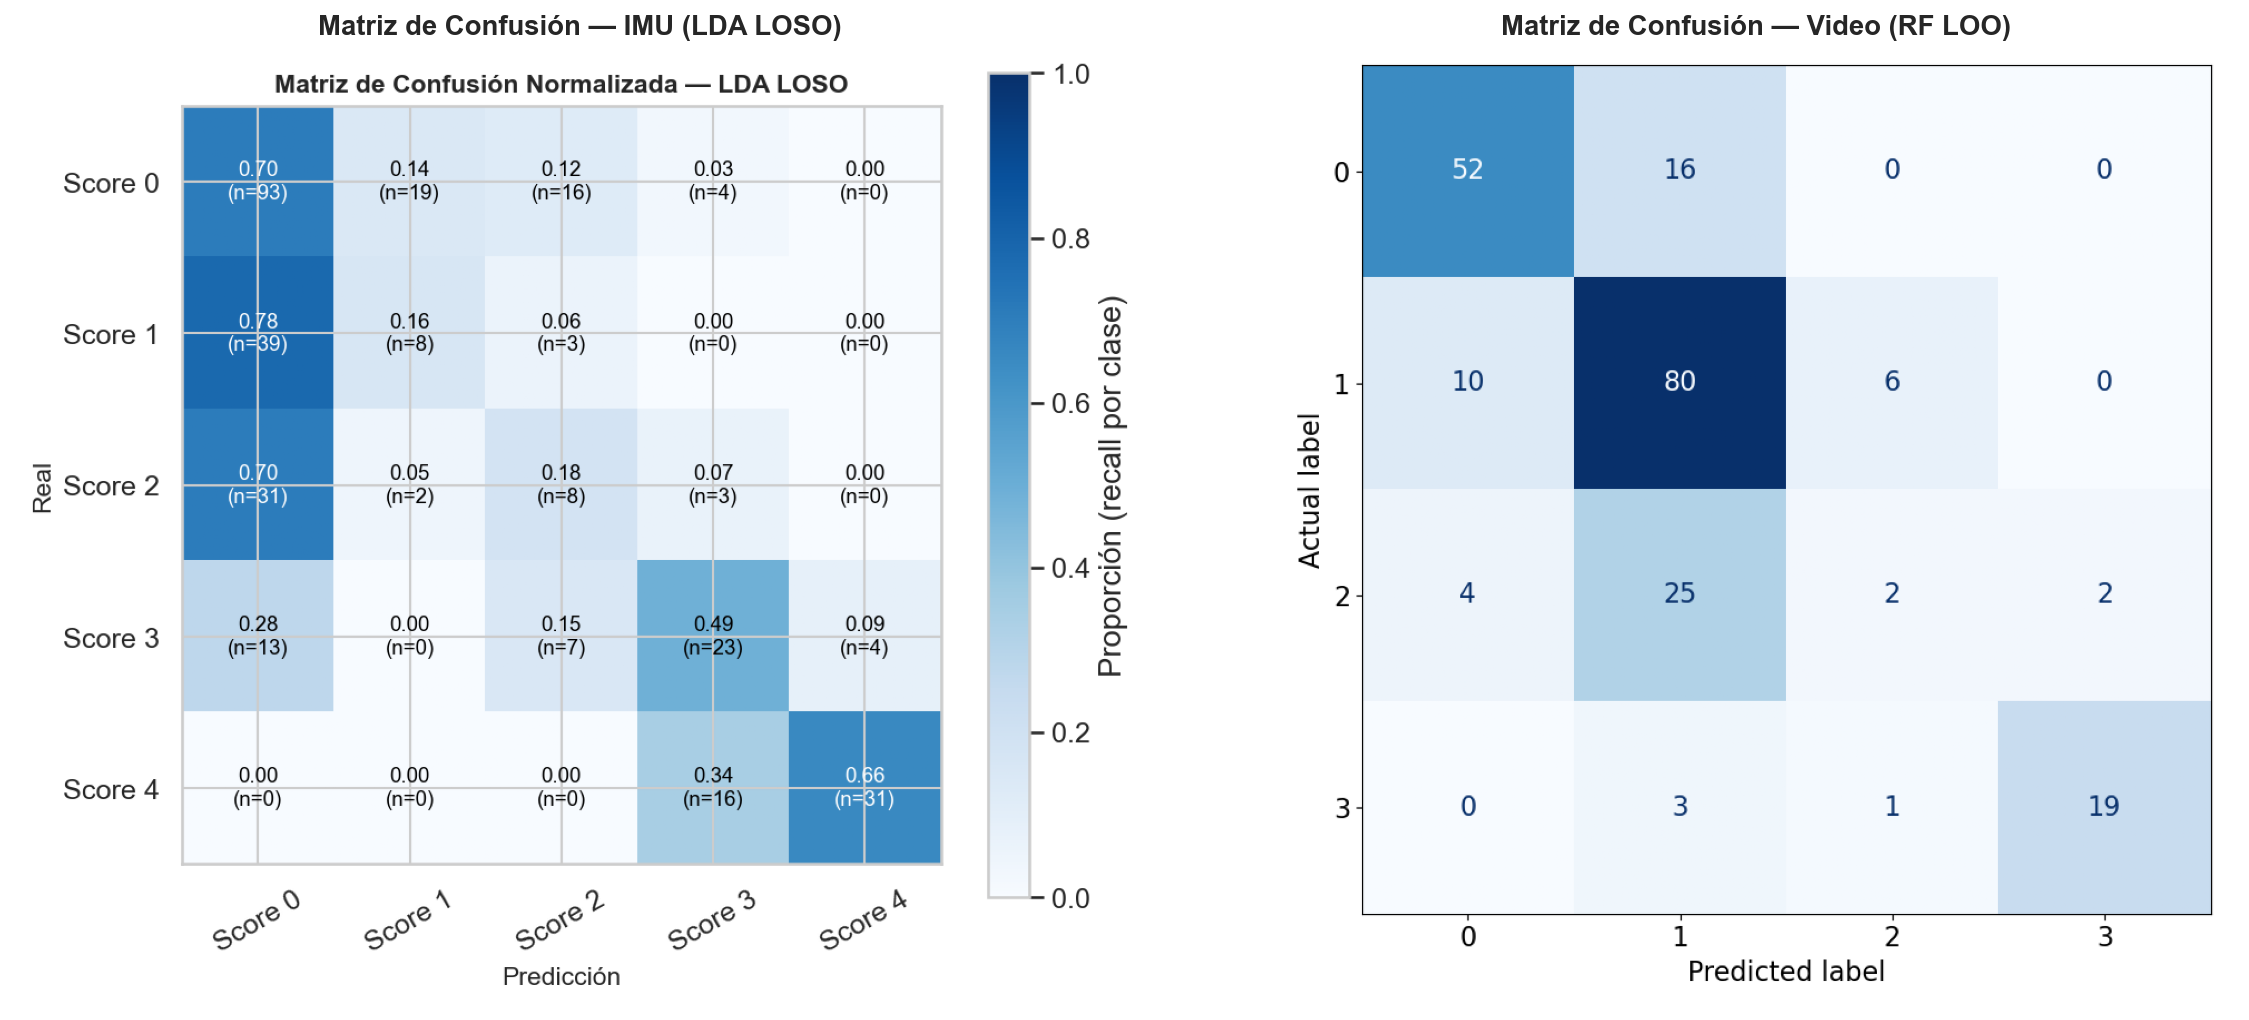

Análisis: Si ambas matrices muestran una 'mancha' de confusión alrededor del Score 2, 
se confirma que la dificultad es intrínseca al movimiento del paciente y no al sensor.


In [8]:
"""
============================================================================
MATRICES DE CONFUSIÓN LADO A LADO
============================================================================
"""

import matplotlib.image as mpimg

# Rutas a las imágenes generadas por los notebooks previos
img_imu = "../../imu_analysis/resultados_golpeteo_completo/figuras/matriz_confusion.png"
img_video = (
    "../results_files/confusion_matrix/fis_classical_cm_RandomForestClassifier.png"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), dpi=150)

try:
    im1 = mpimg.imread(img_imu)
    ax1.imshow(im1)
    ax1.set_title("Matriz de Confusión — IMU (LDA LOSO)", fontweight="bold")
    ax1.axis("off")
except FileNotFoundError:
    ax1.text(
        0.5,
        0.5,
        "⚠️ Imagen IMU no encontrada\nEjecuta el notebook de IMU primero",
        ha="center",
    )

try:
    im2 = mpimg.imread(img_video)
    ax2.imshow(im2)
    ax2.set_title("Matriz de Confusión — Video (RF LOO)", fontweight="bold")
    ax2.axis("off")
except FileNotFoundError:
    ax2.text(
        0.5,
        0.5,
        "⚠️ Imagen Video no encontrada\nEjecuta el notebook de Video primero",
        ha="center",
    )

plt.tight_layout()
plt.savefig(
    os.path.join(Config.RUTA_FIGURAS, "comparacion_matrices.png"), bbox_inches="tight"
)
plt.show()

print(
    "Análisis: Si ambas matrices muestran una 'mancha' de confusión alrededor del Score 2, "
)
print(
    "se confirma que la dificultad es intrínseca al movimiento del paciente y no al sensor."
)

---
## CELDA 9 — Conclusiones y exportación

In [9]:
"""
============================================================================
CONCLUSIONES — Síntesis comparativa y exportación final
============================================================================
"""

print("CONCLUSIÓN 1 — Comparación justa (LDA vs LDA):")
print("El video alcanza una Accuracy comparable al IMU global (~0.59 vs 0.58),")
print("pero el IMU mantiene ventaja en AUC (0.850 vs 0.773).\n")

print("CONCLUSIÓN 2 — Mejor modelo video:")
best_video = _select_best_video(df_classical, df_tsfresh)
if best_video is None:
    print("No se pudo determinar el mejor modelo de video con los summaries disponibles.\n")
else:
    best_name = best_video["Model"]
    best_source = best_video.get("Source", "video")
    best_acc = best_video.get("Accuracy", np.nan)
    best_auc = best_video.get("ROC_AUC", np.nan)
    diff_acc = best_acc - Config.IMU_LDA['global']['Accuracy'] if not np.isnan(best_acc) else np.nan

    print(f"{best_name} ({best_source}) alcanza Acc={best_acc:.3f} y AUC={best_auc:.3f}.")
    if not np.isnan(diff_acc):
        if diff_acc > 0:
            print(f"Supera al LDA IMU en Accuracy por Δ={diff_acc:+.3f}.")
        else:
            print(f"No supera al LDA IMU en Accuracy (Δ={diff_acc:+.3f}).")
    print("Se beneficia de optimización de hiperparámetros en el pipeline de video.\n")

print("CONCLUSIÓN 3 — Features:")
print("Las features rítmicas (ITI, cadencia) son consistentes en ambas modalidades,\n")

print("CONCLUSIÓN 4 — Score 2:")
print("Ambos sistemas sufren en el Score 2, confirmando la ambigüedad clínica de este nivel.\n")

# Exportación final
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
excel_path = os.path.join(Config.RUTA_TABLAS, f'comparacion_completa_{ts}.xlsx')

if not df_classical.empty and not df_tsfresh.empty:
    df_total_models = pd.concat([
        df_classical.assign(Source='classical'),
        df_tsfresh.assign(Source='tsfresh')
    ], ignore_index=True)
elif not df_classical.empty:
    df_total_models = df_classical.copy()
elif not df_tsfresh.empty:
    df_total_models = df_tsfresh.copy()
else:
    df_total_models = pd.DataFrame()

with pd.ExcelWriter(excel_path) as writer:
    if 'df_comp_lda' in locals(): df_comp_lda.to_excel(writer, sheet_name='lda_vs_lda', index=False)
    if not df_total_models.empty: df_total_models.to_excel(writer, sheet_name='todos_modelos', index=False)
    if not df_tsfresh.empty: df_tsfresh.to_excel(writer, sheet_name='tsfresh', index=False)
    if 'df_feat_comp' in locals(): df_feat_comp.to_excel(writer, sheet_name='features_equivalentes', index=False)
    df_cb.to_excel(writer, sheet_name='costo_beneficio', index=False)

print(f"💾 Comparación completa exportada: {excel_path}")

CONCLUSIÓN 1 — Comparación justa (LDA vs LDA):
El video alcanza una Accuracy comparable al IMU global (~0.59 vs 0.58),
pero el IMU mantiene ventaja en AUC (0.850 vs 0.773).

CONCLUSIÓN 2 — Mejor modelo video:
RandomForestClassifier (classical) alcanza Acc=0.695 y AUC=0.809.
Supera al LDA IMU en Accuracy por Δ=+0.124.
Se beneficia de optimización de hiperparámetros en el pipeline de video.

CONCLUSIÓN 3 — Features:
Las features rítmicas (ITI, cadencia) son consistentes en ambas modalidades,

CONCLUSIÓN 4 — Score 2:
Ambos sistemas sufren en el Score 2, confirmando la ambigüedad clínica de este nivel.

💾 Comparación completa exportada: ../results_files/comparacion_imu_video/tablas/comparacion_completa_20260510_192422.xlsx
